<a href="https://colab.research.google.com/github/KIRANVVIT/CODE-FOBE-PROBLEM-STATEMENTS/blob/main/week16_practice_kiran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ** Introduction to Web Scraping & Fetching Web Pages**

Note: we will use this website to scrape data
website link: https://www.octoparse.com/template/walmart-product-scraper
https://www.octoparse.com/template/amazon-product-scraper-by-keywords

In [ ]:
# Install the Required Libraries
!pip install beautifulsoup4 requests pandas

✅ Webpage fetched successfully!
200
<!DOCTYPE html><html lang="en"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width"/><script type="application/ld+json">{"@context":"https://schema.org","@graph":[{"@type":"Organization","@id":"https://www.octoparse.com/#organization","name":"Octoparse","legalName":"Octopus Data Inc.","url":"https://www.octoparse.com","logo":{"@type":"ImageObject","url":"https://www.octoparse.com/static/logo.svg"},"description":"Octoparse is a no-code web scraping platform that lets anyone extract structured data from any website without coding, with cloud extraction, scheduled tasks, ready-to-use templates, and an open platform (API, MCP, and CLI) for AI and developer workflows.","sameAs":["https://www.linkedin.com/company/octopus-data-inc.","https://twitter.com/Octoparse","https://www.youtube.com/channel/UCweDWm1QY2G67SDAKX7nreg","https://github.com/octoparse","https://www.reddit.com/r/OctoparseCommuity/","https://discord.gg/zCq9WDmEPa"]}
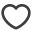
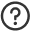
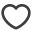
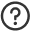
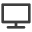
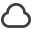

In [ ]:
#1.Fetch the Walmart Product Page (Get the Webpage).use requests library to retrieve the webpage from Walmart.
#2.Parse the HTML to Locate Desired Data.Use BeautifulSoup to read the messy web code (HTML).Extract specific data like product names, prices, and ratings.
#3.Store the Extracted Data into an SQLite Database (Save for Later)Use sqlite3 to save the collected data into a local database.
#4.Analyze the Stored Data Using SQL Queries Use SQL queries to sort, filter, or find insights from the stored data.

# Install the Required Libraries
#beautifulsoup4 → Reads and extracts data from HTML.
#requests → Fetches the webpage’s HTML.
#pandas → Organizes extracted data into a table.

from bs4 import BeautifulSoup
import requests
import pandas as pd

# Fetch the Webpage’s HTML Content. We need to download the webpage’s content so Python can read it.
# Define the webpage URL (Replace with an actual product page URL)
url = "https://www.octoparse.com/template/amazon-product-scraper-by-keywords"

# Fetch the page content
response = requests.get(url)  #Fetches the webpage’s raw HTML code.

# Check if the request was successful (status code 200)
if response.status_code == 200:
    print("✅ Webpage fetched successfully!")
else:
    print("❌ Failed to fetch webpage. Check the URL.")

#print(response.status_code)    #200
#print(response.text)    # messy html code

#Parsing Web Content with BeautifulSoup



Below code is just to understand HTML code dont run this cell

In [ ]:
<!DOCTYPE html>
<html>
 <head>
  <title>
   Walmart - Product Page
  </title>
 </head>
 <body>
  <div class="table-scroll-box">
   <table>
    <tbody>
     <tr>
      <td>Product Name</td>
      <td>Product ID</td>
      <td>Price</td>
     </tr>
     <tr>
      <td>Laptop</td>
      <td>101</td>
      <td>$800</td>
     </tr>
     <tr>
      <td>Smartphone</td>
      <td>102</td>
      <td>$500</td>
     </tr>
    </tbody>
   </table>
  </div>
 </body>
</html>


SyntaxError: invalid syntax (2045361873.py, line 1)

In [ ]:
#Parsing the HTML with BeautifulSoup
#Convert Raw HTML into a Readable Format

# Import the BeautifulSoup library
from bs4 import BeautifulSoup
import requests
import pandas as pd

url = "https://www.octoparse.com/template/amazon-product-scraper-by-keywords"

# Fetch the page content
response = requests.get(url)  #Fetches the webpage’s raw HTML code.

# Check if the request was successful (status code 200)
if response.status_code == 200:
    print("✅ Webpage fetched successfully!")
else:
    print("❌ Failed to fetch webpage. Check the URL.")

# Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")


✅ Webpage fetched successfully!


In [ ]:
#Print a Small Part of the HTML to See the Structure
print(soup.prettify()[5000:21000])

": [
      {
        "@type": "Question",
        "name": "1. Can I scrape Amazon product details?",
        "acceptedAnswer": {
          "@type": "Answer",
          "text": "No. This template is designed to collect product metadata from Amazon search results by keyword. It does not open each product detail page to extract deeper product information such as bullet points, product descriptions, specifications, variants, or best seller ranks. If you need detailed product data, first use this keyword scraper to collect ASINs, then run the product details template for your target Amazon marketplace. MarketplaceTemplate nameTemplate URLFAQ noteUnited StatesAmazon Product Scraper (for US)https://www.octoparse.com/template/amazon-product-details-scraperRecommended primary US details templateSpainAmazon Product Details Scraper (for Spain)https://www.octoparse.com/template/amazon-producto-detalles-scraper-asinUse for Amazon Spain product detailsGermanyAmazonDetails ASIN Scraper (for Germany)h

In [ ]:
#Code to Find the Table in the Webpage
# Locate the table – here we assume it's the first <table> on the page.
# You may need to adjust the selector if the table is nested or has an id/class.
table = soup.find('table')

# Check if the table exists
if table:
    print("✅ Table found!")
else:
    print("❌ Table not found. Check the class name.")


✅ Table found!


In [ ]:
#Extract All Rows from the Table
rows = table.find_all('tr')

# Print the total number of rows found
print(f"✅ Found {len(rows)} rows in the table.")

# Print the first few rows (formatted)
print("\n🔹 First 3 Rows (Formatted Output):\n")

# Print the first 3 rows directly
for i in range(3):
    print(f"Row {i + 1}: {rows[i]}\n")  # Print row

✅ Found 8 rows in the table.

🔹 First 3 Rows (Formatted Output):

Row 1: <tr><th colspan="1" rowspan="1" width="70"><div class="t-max-height" data-tooltip-content="Site" data-tooltip-id="table-content-tooltip" style="max-width:122px">Site</div></th><th colspan="1" rowspan="1" width="70"><div class="t-max-height" data-tooltip-content="Keyword" data-tooltip-id="table-content-tooltip" style="max-width:122px">Keyword</div></th><th colspan="1" rowspan="1" width="70"><div class="t-max-height" data-tooltip-content="Product_name" data-tooltip-id="table-content-tooltip" style="max-width:122px">Product_name</div></th><th colspan="1" rowspan="1" width="70"><div class="t-max-height" data-tooltip-content="Product_page" data-tooltip-id="table-content-tooltip" style="max-width:122px">Product_page</div></th><th colspan="1" rowspan="1" width="70"><div class="t-max-height" data-tooltip-content="ASIN" data-tooltip-id="table-content-tooltip" style="max-width:122px">ASIN</div></th><th colspan="1" rowspan="

In [ ]:
# Extract Product Data from Each Row  (< td >)
#1.Prepare a List to Store Extracted Data
data = []
#2.Skip the Header Row and Loop Through the Rows to extract Data from the Remaining Rows
# Assume the first row is the header, so iterate over the remaining rows
for row in rows[1:]:
    cells = row.find_all('td')
    # Check if there are enough cells
    if len(cells) < 11:
        continue

    # Extract text from each cell for the columns you need:
    product_name      = cells[2].get_text(strip=True)
    product_id        = cells[4].get_text(strip=True)
    current_price     = cells[8].get_text(strip=True)
    original_price    = cells[9].get_text(strip=True)
    rating            = cells[5].get_text(strip=True)
    review_count      = cells[6].get_text(strip=True)
    shipping_info     = cells[11].get_text(strip=True)

    # Append a dictionary of the row data
    data.append({
        "Product Name": product_name,
        "Product ID": product_id,
        "Current Price": current_price,
        "Original Price": original_price,
        "Rating": rating,
        "Review Count": review_count,
        "Shipping Information": shipping_info
    })

# Convert Extracted Data into a DataFrame and Display It
df = pd.DataFrame(data)

# Display the dataframe
df


,Product Name,Product ID,Current Price,Original Price,Rating,Review Count,Shipping Information
0,"Apple iPhone SE (2nd Generation), US Version, ...",B088NQSLGN,$123.75,$156.86,4.2 out of 5 stars,"19,209","Thu, Nov 7"
1,"Apple iPhone SE 3rd Gen, 64GB, Starlight - Unl...",B0BDY74L2P,$175.75,$195.00,4.2 out of 5 stars,"2,033","Thu, Nov 7"
2,"Apple iPhone XS, US Version, 256GB, Gold - Unl...",B07KKL5KGG,$203.00,$304.95,4.1 out of 5 stars,"2,375","Wed, Nov 6"
3,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"
4,"Apple iPhone 14 Plus, 128GB, Midnight for AT&T...",B0BN95PXNV,$418.99,$463.48,3.4 out of 5 stars,20,Nov 7 - 12
5,"Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...",B0BYM42RZ1,$844.97,$896.00,4.3 out of 5 stars,533,"Thu, Nov 7"
6,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"


===============================================================================session 2

Part FOUR: Storing extracted data in SQL database & Analyzing Data with SQL

In [ ]:
#Creating an SQLite Database in Google Colab


import sqlite3

# ✅ Assuming you already have a DataFrame named 'df'

# ✅ Connect to (or create) the SQLite database
conn = sqlite3.connect("amazon_products.db")

# ✅ Insert the DataFrame into a table named 'Products'
df.to_sql("Products", conn, if_exists='replace', index=False)

# ✅ Commit changes and close the connection
conn.commit()
conn.close()

print("✅ Data has been successfully inserted into the 'Products' table.")


✅ Data has been successfully inserted into the 'Products' table.


✅ Result: A new file named amazon_products.db is created with a products table.

📥 Saving Extracted DataFrame into a Table

* ✅ if_exists="replace" ensures the table is replaced with new data each time.
* If you want to add data without replacing existing rows, use if_exists="append" instead.

In [ ]:
# Verifying the Stored Data:

import pandas as pd

# ✅ Connect to the SQLite database
conn = sqlite3.connect("amazon_products.db")

# ✅ Retrieve data from the 'Products' table
stored_df = pd.read_sql("SELECT * FROM Products", conn)

# ✅ Display the retrieved DataFrame
print("📄 Retrieved Data from 'Products' Table:")


# ✅ Close the connection
conn.close()
stored_df

📄 Retrieved Data from 'Products' Table:


,Product Name,Product ID,Current Price,Original Price,Rating,Review Count,Shipping Information
0,"Apple iPhone SE (2nd Generation), US Version, ...",B088NQSLGN,$123.75,$156.86,4.2 out of 5 stars,"19,209","Thu, Nov 7"
1,"Apple iPhone SE 3rd Gen, 64GB, Starlight - Unl...",B0BDY74L2P,$175.75,$195.00,4.2 out of 5 stars,"2,033","Thu, Nov 7"
2,"Apple iPhone XS, US Version, 256GB, Gold - Unl...",B07KKL5KGG,$203.00,$304.95,4.1 out of 5 stars,"2,375","Wed, Nov 6"
3,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"
4,"Apple iPhone 14 Plus, 128GB, Midnight for AT&T...",B0BN95PXNV,$418.99,$463.48,3.4 out of 5 stars,20,Nov 7 - 12
5,"Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...",B0BYM42RZ1,$844.97,$896.00,4.3 out of 5 stars,533,"Thu, Nov 7"
6,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"


In [ ]:
#Analyzing Data with SQL
#1.Your task is to retrieve only the product names from the products table.
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("amazon_products.db")

# ✅ Corrected SQL query using backticks for column name with space
query = "SELECT `Product Name` FROM products;"

# ✅ Execute the query and fetch results into a DataFrame
product_names_df = pd.read_sql(query, conn)

# ✅ Display the retrieved product names
print("📄 Retrieved Product Names:")
print(product_names_df)

# ✅ Close the connection
conn.close()


📄 Retrieved Product Names:
                                        Product Name
0  Apple iPhone SE (2nd Generation), US Version, ...
1  Apple iPhone SE 3rd Gen, 64GB, Starlight - Unl...
2  Apple iPhone XS, US Version, 256GB, Gold - Unl...
3  Apple iPhone 11 Pro, 256GB, Midnight Green - U...
4  Apple iPhone 14 Plus, 128GB, Midnight for AT&T...
5  Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...
6  Apple iPhone 11 Pro, 256GB, Midnight Green - U...


In [ ]:
#2. Identify Top-Rated Products Based on Customer Reviews:

# ✅ Connect to the database
conn = sqlite3.connect("amazon_products.db")

# ✅ Query: Find products with Rating >= 4.2
query_top_rated = """
SELECT `Product Name`, Rating
FROM products
WHERE CAST(REPLACE(Rating, '$', '') AS REAL) >= 4.2
ORDER BY CAST(REPLACE(Rating, '$', '') AS REAL) DESC;
"""

# ✅ Execute the query
top_rated_products = pd.read_sql(query_top_rated, conn)

# ✅ Display top-rated products
print("🌟 Top-Rated Products (Rating ≥ 4.2):")
print(top_rated_products)


🌟 Top-Rated Products (Rating ≥ 4.2):
                                        Product Name              Rating
0  Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...  4.3 out of 5 stars
1  Apple iPhone SE (2nd Generation), US Version, ...  4.2 out of 5 stars
2  Apple iPhone SE 3rd Gen, 64GB, Starlight - Unl...  4.2 out of 5 stars


In [ ]:
#3. write SQL query to find products with the highest number of reviews and high ratings (≥ 4.2):
import sqlite3
import pandas as pd

# ✅ Connect to the database
conn = sqlite3.connect("amazon_products.db")

# ✅ SQL query to find products with high reviews (> 100) and high ratings (≥ 4.2)
query_high_reviews_high_rating = """
SELECT `Product Name`, `Review Count`, Rating
FROM products
WHERE CAST(`Review Count` AS INTEGER) > 100
  AND CAST(REPLACE(Rating, '$', '') AS REAL) >= 4.2
ORDER BY CAST(`Review Count` AS INTEGER) DESC;
"""

# ✅ Execute the query and fetch results into a DataFrame
high_reviews_high_rating_df = pd.read_sql(query_high_reviews_high_rating, conn)

# ✅ Display the retrieved products
print("🌟 Products with High Number of Reviews (>100) and High Ratings (≥ 4.2):")
print(high_reviews_high_rating_df)

# ✅ Close the connection
conn.close()


🌟 Products with High Number of Reviews (>100) and High Ratings (≥ 4.2):
                                        Product Name Review Count  \
0  Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...          533   

               Rating  
0  4.3 out of 5 stars  


In [ ]:
stored_df

,Product Name,Product ID,Current Price,Original Price,Rating,Review Count,Shipping Information
0,"Apple iPhone SE (2nd Generation), US Version, ...",B088NQSLGN,$123.75,$156.86,4.2 out of 5 stars,"19,209","Thu, Nov 7"
1,"Apple iPhone SE 3rd Gen, 64GB, Starlight - Unl...",B0BDY74L2P,$175.75,$195.00,4.2 out of 5 stars,"2,033","Thu, Nov 7"
2,"Apple iPhone XS, US Version, 256GB, Gold - Unl...",B07KKL5KGG,$203.00,$304.95,4.1 out of 5 stars,"2,375","Wed, Nov 6"
3,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"
4,"Apple iPhone 14 Plus, 128GB, Midnight for AT&T...",B0BN95PXNV,$418.99,$463.48,3.4 out of 5 stars,20,Nov 7 - 12
5,"Apple iPhone 14 Pro Max, 256GB, Deep Purple - ...",B0BYM42RZ1,$844.97,$896.00,4.3 out of 5 stars,533,"Thu, Nov 7"
6,"Apple iPhone 11 Pro, 256GB, Midnight Green - U...",B07ZQPYXJP,$302.00,$379.00,4.0 out of 5 stars,"2,527","Wed, Nov 6"


/tmp/ipykernel_1813/1171487854.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


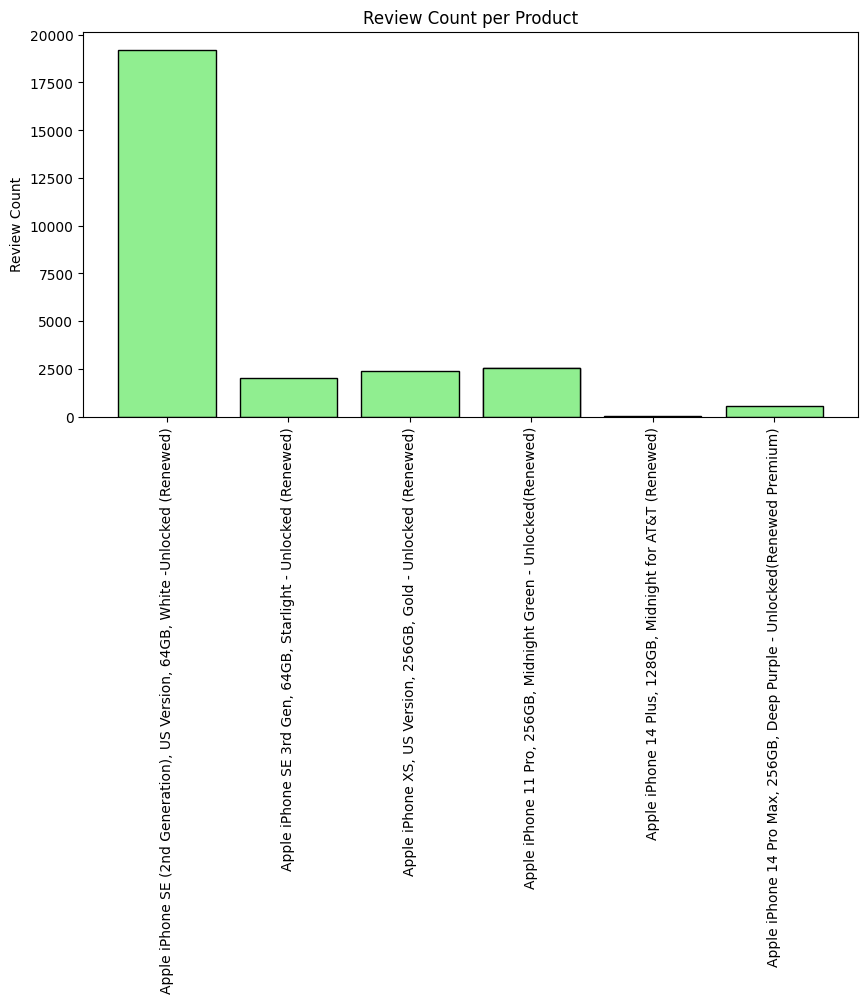

In [ ]:
# Visualizing the Extracted Amazon product Data
#visualizing the Review Count per Product,
# ✅Bar Chart - Product Names vs. Review Count
import matplotlib.pyplot as plt

# Remove commas from the 'Review Count' column before converting to numeric
# Ensure the column is treated as string before applying .str accessor
stored_df['Review Count'] = stored_df['Review Count'].astype(str).str.replace(',', '', regex=False)
stored_df['Review Count'] = pd.to_numeric(stored_df['Review Count'])


# ✅ Chart customization
plt.figure(figsize=(10, 5))
plt.bar(stored_df['Product Name'], stored_df['Review Count'], color='lightgreen', edgecolor='black')
plt.xticks(rotation=90)
plt.ylabel("Review Count")
plt.title("Review Count per Product") # Removed the emoji from the title
plt.tight_layout()
plt.show()